In [1]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, Subset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from PIL import Image


In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR    = "Spiral_HandPD"
IMG_SIZE    = 64          # lightweight: 64x64 for AE & GAN
BATCH_SIZE  = 16
EPOCHS_AE   = 30
EPOCHS_GAN  = 50
LATENT_DIM  = 128         # AE bottleneck size
NOISE_DIM   = 100         # GAN generator input noise
print(f"Device: {DEVICE}")


Device: cpu


SpiralControl: 72 images
SpiralPatients: 296 images


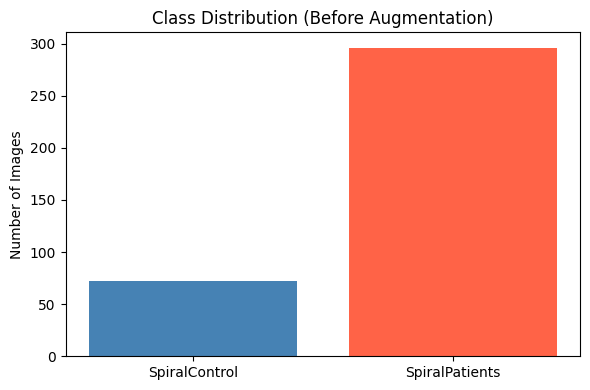


Dataset is imbalanced. GAN will be trained on SpiralPatients to augment minority class.


In [3]:
classes = {"SpiralControl": 0, "SpiralPatients": 1}
counts = {}
for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    counts[cls] = len(os.listdir(path))
    print(f"{cls}: {counts[cls]} images")

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["steelblue", "tomato"])
plt.title("Class Distribution (Before Augmentation)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

print("\nDataset is imbalanced. GAN will be trained on SpiralPatients to augment minority class.")


In [ ]:
ae_gan_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),   
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) 
])


viz_transform = ae_gan_transform


In [5]:
class SpiralDataset(Dataset):
    """General dataset for AE / GAN: returns (image, label)."""
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        class_to_idx = {"SpiralControl": 0, "SpiralPatients": 1}
        for cls, idx in class_to_idx.items():
            cls_dir = os.path.join(root_dir, cls)
            for f in os.listdir(cls_dir):
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.samples.append((os.path.join(cls_dir, f), idx))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class PatientOnlyDataset(Dataset):
    """Returns only SpiralPatients images — used for GAN training."""
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        cls_dir = os.path.join(root_dir, "SpiralPatients")
        self.files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


full_dataset    = SpiralDataset(DATA_DIR, transform=ae_gan_transform)
patient_dataset = PatientOnlyDataset(DATA_DIR, transform=ae_gan_transform)

print(f"Full dataset  : {len(full_dataset)} samples")
print(f"Patient-only  : {len(patient_dataset)} samples (GAN training set)")


Full dataset  : 368 samples
Patient-only  : 296 samples (GAN training set)


Train: 294 | Val: 37 | Test: 37
Patient-GAN loader batches: 19


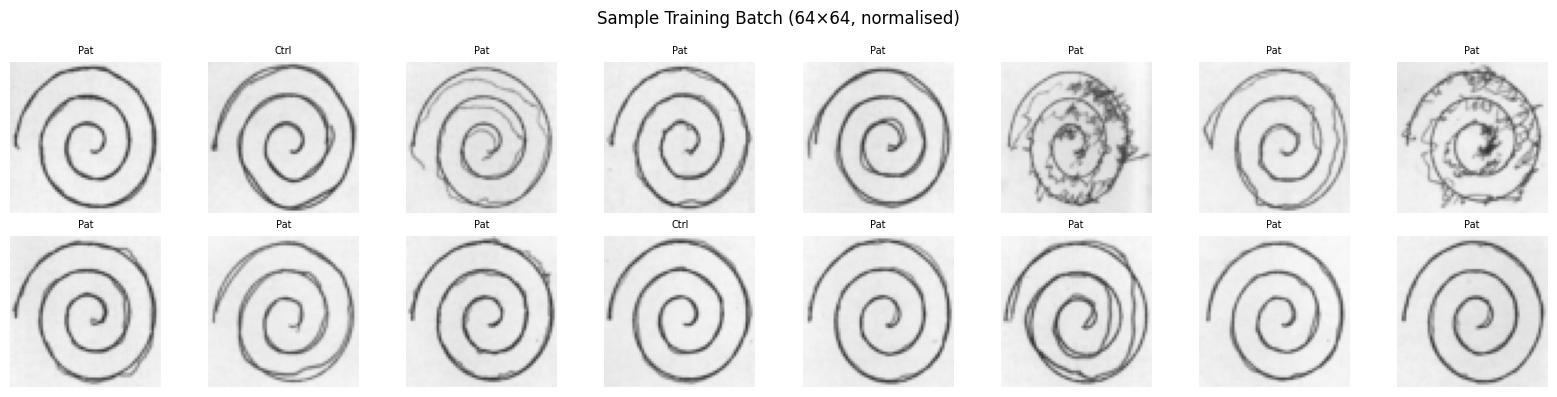

In [6]:
indices = list(range(len(full_dataset)))
labels  = [full_dataset.samples[i][1] for i in indices]

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, labels, test_size=0.2, stratify=labels, random_state=SEED)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

train_set = Subset(full_dataset, train_idx)
val_set   = Subset(full_dataset, val_idx)
test_set  = Subset(full_dataset, test_idx)

ae_loader      = DataLoader(train_set,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader     = DataLoader(val_set,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader    = DataLoader(test_set,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
patient_loader = DataLoader(patient_dataset,batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Patient-GAN loader batches: {len(patient_loader)}")

# ── visualise a sample batch ──
imgs, lbls = next(iter(ae_loader))
mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
std  = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = (imgs[i] * std + mean).clamp(0, 1)
    ax.imshow(img.permute(1,2,0))
    ax.set_title("Ctrl" if lbls[i]==0 else "Pat", fontsize=7)
    ax.axis("off")
plt.suptitle("Sample Training Batch (64×64, normalised)")
plt.tight_layout(); plt.show()


In [7]:
class Encoder(nn.Module):
    """CNN Encoder: 3×64×64 → latent_dim"""
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            # 3×64×64 → 32×32×32
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            # 32×32×32 → 64×16×16
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            # 64×16×16 → 128×8×8
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            # 128×8×8 → 256×4×4
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc(h)


class Decoder(nn.Module):
    """CNN Decoder: latent_dim → 3×64×64"""
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            # 256×4×4 → 128×8×8
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            # 128×8×8 → 64×16×16
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            # 64×16×16 → 32×32×32
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            # 32×32×32 → 3×64×64
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1), nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.deconv(h)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z   # return recon + latent


ae_model = Autoencoder(LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f"Autoencoder total parameters: {total_params:,}")
print(f"  Encoder: {sum(p.numel() for p in ae_model.encoder.parameters()):,}")
print(f"  Decoder: {sum(p.numel() for p in ae_model.decoder.parameters()):,}")


Autoencoder total parameters: 2,434,243
  Encoder: 1,215,520
  Decoder: 1,218,723


In [8]:
def train_ae(model, train_loader, val_loader, epochs=30, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss, best_weights = float('inf'), None

    for epoch in range(epochs):
        # ── train ──
        model.train()
        t_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = model(imgs)
            loss = criterion(recon, imgs)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * imgs.size(0)
        t_loss /= len(train_loader.dataset)

        # ── validate ──
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                recon, _ = model(imgs)
                v_loss += criterion(recon, imgs).item() * imgs.size(0)
        v_loss /= len(val_loader.dataset)

        scheduler.step()
        train_losses.append(t_loss)
        val_losses.append(v_loss)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}]  Train Loss: {t_loss:.5f}  Val Loss: {v_loss:.5f}")

    model.load_state_dict(best_weights)
    print(f"\nBest Val Loss: {best_val_loss:.5f}")
    return train_losses, val_losses


print("Training Autoencoder...")
ae_train_losses, ae_val_losses = train_ae(ae_model, ae_loader, val_loader,
                                           epochs=EPOCHS_AE, lr=1e-3)


Training Autoencoder...
Epoch [  5/30]  Train Loss: 0.04946  Val Loss: 0.04834
Epoch [ 10/30]  Train Loss: 0.03338  Val Loss: 0.03438
Epoch [ 15/30]  Train Loss: 0.02664  Val Loss: 0.03036
Epoch [ 20/30]  Train Loss: 0.02259  Val Loss: 0.02644
Epoch [ 25/30]  Train Loss: 0.02018  Val Loss: 0.02493
Epoch [ 30/30]  Train Loss: 0.01842  Val Loss: 0.02414

Best Val Loss: 0.02413


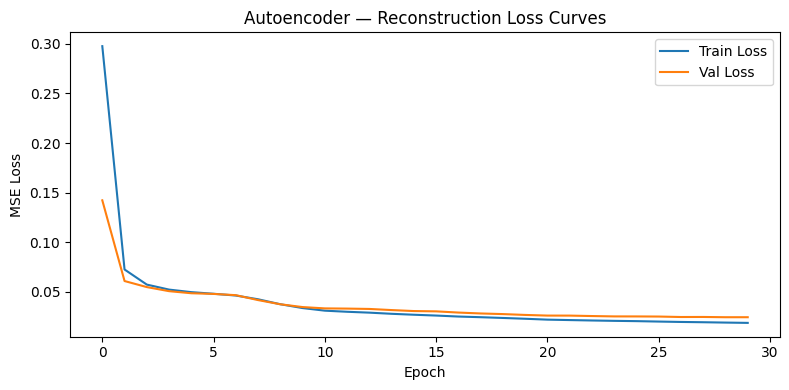

Final Train Loss : 0.01842
Final Val   Loss : 0.02414
Best Val    Loss : 0.02413  @ epoch 29


In [9]:
plt.figure(figsize=(8, 4))
plt.plot(ae_train_losses, label="Train Loss")
plt.plot(ae_val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Autoencoder — Reconstruction Loss Curves")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Final Train Loss : {ae_train_losses[-1]:.5f}")
print(f"Final Val   Loss : {ae_val_losses[-1]:.5f}")
print(f"Best Val    Loss : {min(ae_val_losses):.5f}  @ epoch {ae_val_losses.index(min(ae_val_losses))+1}")


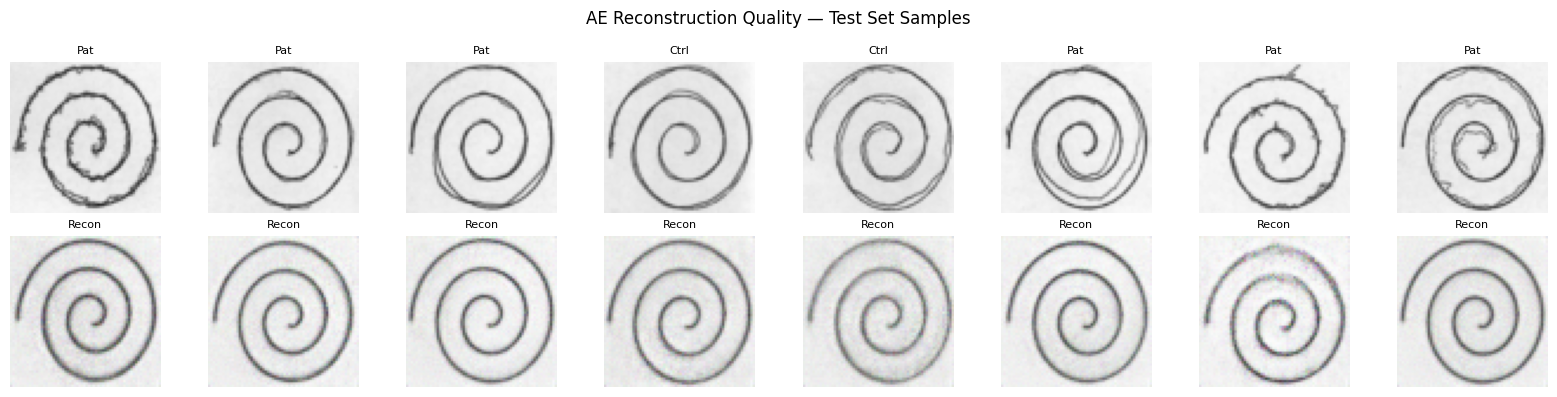

Test set — Mean MSE : 0.02476
Test set — Std  MSE : 0.01159


In [10]:
ae_model.eval()
imgs, lbls = next(iter(test_loader))
imgs = imgs.to(DEVICE)
with torch.no_grad():
    recons, _ = ae_model(imgs)

denorm = lambda t: (t * 0.5 + 0.5).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))
for i in range(n):
    axes[0, i].imshow(denorm(imgs[i]))
    axes[0, i].set_title(f"{'Ctrl' if lbls[i]==0 else 'Pat'}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(denorm(recons[i]))
    axes[1, i].set_title("Recon", fontsize=8)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("AE Reconstruction Quality — Test Set Samples")
plt.tight_layout(); plt.show()

# Quantitative: per-sample MSE on test set
mse_per_sample = []
ae_model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(DEVICE)
        recons, _ = ae_model(imgs)
        mse_per_sample.extend(((recons - imgs)**2).mean(dim=[1,2,3]).cpu().numpy())

print(f"Test set — Mean MSE : {np.mean(mse_per_sample):.5f}")
print(f"Test set — Std  MSE : {np.std(mse_per_sample):.5f}")


Latent matrix shape : (37, 128)
PCA explained variance ratio: [0.35406387 0.2786931 ]


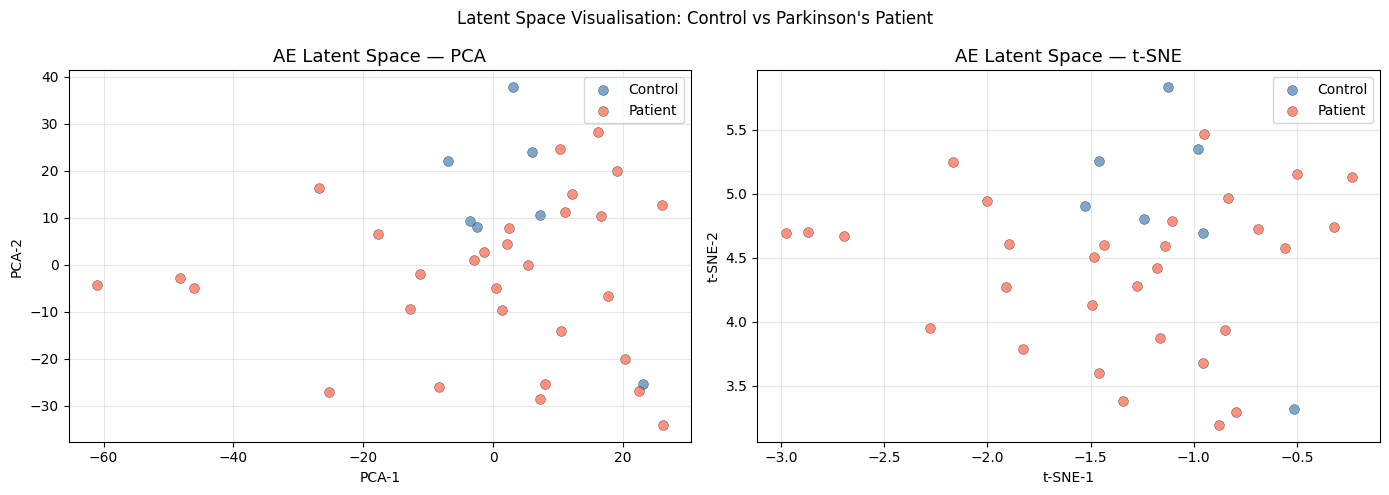

In [ ]:
ae_model.eval()
latents, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        _, z = ae_model(imgs.to(DEVICE))
        latents.append(z.cpu().numpy())
        all_labels.extend(lbls.numpy())

latents     = np.vstack(latents)
all_labels  = np.array(all_labels)
class_names = ["Control", "Patient"]
colors      = ["steelblue", "tomato"]

print(f"Latent matrix shape : {latents.shape}")


pca  = PCA(n_components=2, random_state=SEED)
z_pca = pca.fit_transform(latents)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")


tsne  = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
z_tsne = tsne.fit_transform(latents)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, title in zip(axes, [z_pca, z_tsne], ["PCA", "t-SNE"]):
    for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
        mask = all_labels == cls_idx
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=cls_name,
                   alpha=0.7, edgecolors='k', linewidths=0.3, s=50)
    ax.set_title(f"AE Latent Space — {title}", fontsize=13)
    ax.set_xlabel(f"{title}-1"); ax.set_ylabel(f"{title}-2")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Latent Space Visualisation: Control vs Parkinson's Patient")
plt.tight_layout(); plt.show()


In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),   nn.ReLU(True),

            nn.ConvTranspose2d(ngf,  3,      4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), -1, 1, 1))


class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf,    4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf,   ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf*8, 1,     4, 1, 0, bias=False), nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G = Generator(NOISE_DIM).to(DEVICE).apply(weights_init)
D = Discriminator().to(DEVICE).apply(weights_init)

print(f"Generator     params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")


Generator     params: 3,576,704
Discriminator params: 2,765,568


In [14]:
criterion_gan = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Fixed noise for visual progress tracking
fixed_noise = torch.randn(16, NOISE_DIM, device=DEVICE)

G_losses, D_losses = [], []

print("Training DCGAN on SpiralPatients...")
for epoch in range(EPOCHS_GAN):
    g_loss_ep, d_loss_ep, n_batches = 0, 0, 0

    for real_imgs in patient_loader:
        real_imgs = real_imgs.to(DEVICE)
        bsz = real_imgs.size(0)

        # ── Train Discriminator ──
        D.zero_grad()
        real_labels = torch.full((bsz,), 0.9, device=DEVICE)   # label smoothing
        fake_labels = torch.zeros(bsz, device=DEVICE)

        out_real = D(real_imgs)
        loss_D_real = criterion_gan(out_real, real_labels)

        noise = torch.randn(bsz, NOISE_DIM, device=DEVICE)
        fake_imgs = G(noise)
        out_fake = D(fake_imgs.detach())
        loss_D_fake = criterion_gan(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ──
        G.zero_grad()
        out_fake2 = D(fake_imgs)
        loss_G = criterion_gan(out_fake2, torch.ones(bsz, device=DEVICE))
        loss_G.backward()
        opt_G.step()

        g_loss_ep += loss_G.item()
        d_loss_ep += loss_D.item()
        n_batches += 1

    G_losses.append(g_loss_ep / n_batches)
    D_losses.append(d_loss_ep / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS_GAN}]  "
              f"D Loss: {D_losses[-1]:.4f}  G Loss: {G_losses[-1]:.4f}")

print("GAN training complete.")


Training DCGAN on SpiralPatients...
Epoch [ 10/50]  D Loss: 0.4761  G Loss: 10.9200
Epoch [ 20/50]  D Loss: 0.5179  G Loss: 7.3104
Epoch [ 30/50]  D Loss: 0.4506  G Loss: 6.9204
Epoch [ 40/50]  D Loss: 0.5580  G Loss: 6.6025
Epoch [ 50/50]  D Loss: 0.5319  G Loss: 5.8389
GAN training complete.


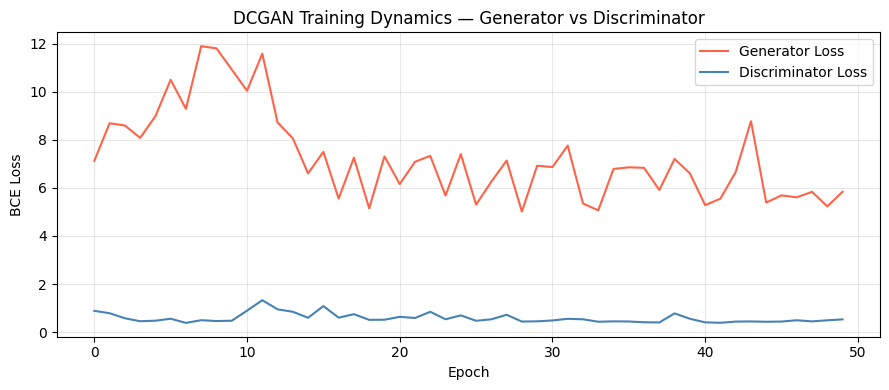

Final G Loss: 5.8389
Final D Loss: 0.5319
G/D ratio   : 10.977  (healthy range ≈ 0.5–2.0)
⚠  Discriminator may be collapsing — G too strong.


In [15]:
plt.figure(figsize=(9, 4))
plt.plot(G_losses, label="Generator Loss",     color="tomato")
plt.plot(D_losses, label="Discriminator Loss", color="steelblue")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("DCGAN Training Dynamics — Generator vs Discriminator")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Final G Loss: {G_losses[-1]:.4f}")
print(f"Final D Loss: {D_losses[-1]:.4f}")
ratio = G_losses[-1] / (D_losses[-1] + 1e-8)
print(f"G/D ratio   : {ratio:.3f}  (healthy range ≈ 0.5–2.0)")
if ratio < 0.1:
    print("⚠  Generator may be collapsing — D too strong.")
elif ratio > 10:
    print("⚠  Discriminator may be collapsing — G too strong.")
else:
    print("✓  Training appears stable.")


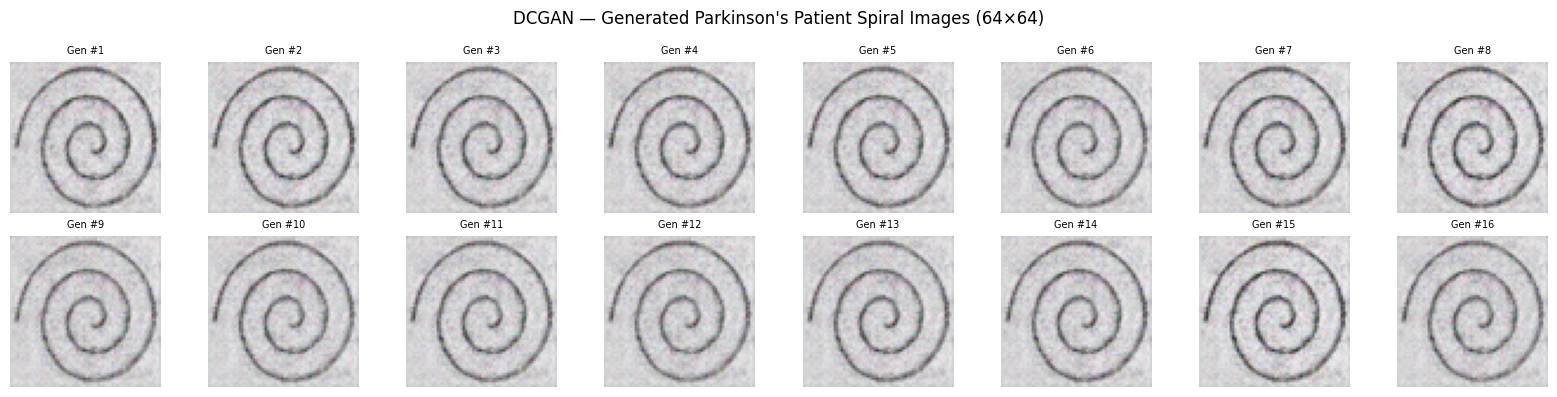


Pixel-wise std across 64 generated images: 0.0273
(Higher std → more diversity, less mode collapse)


In [16]:
G.eval()
with torch.no_grad():
    gen_imgs = G(fixed_noise).cpu()

denorm = lambda t: (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(denorm(gen_imgs[i]))
    ax.set_title(f"Gen #{i+1}", fontsize=7)
    ax.axis("off")
plt.suptitle("DCGAN — Generated Parkinson's Patient Spiral Images (64×64)")
plt.tight_layout(); plt.show()

# ── Mode collapse check: diversity of generated images ──
noise_batch = torch.randn(64, NOISE_DIM, device=DEVICE)
G.eval()
with torch.no_grad():
    gen_batch = G(noise_batch).cpu().numpy()

# Pixel-wise std across generated images — higher = more diverse
pixel_std = gen_batch.std(axis=0).mean()
print(f"\nPixel-wise std across 64 generated images: {pixel_std:.4f}")
print("(Higher std → more diversity, less mode collapse)")


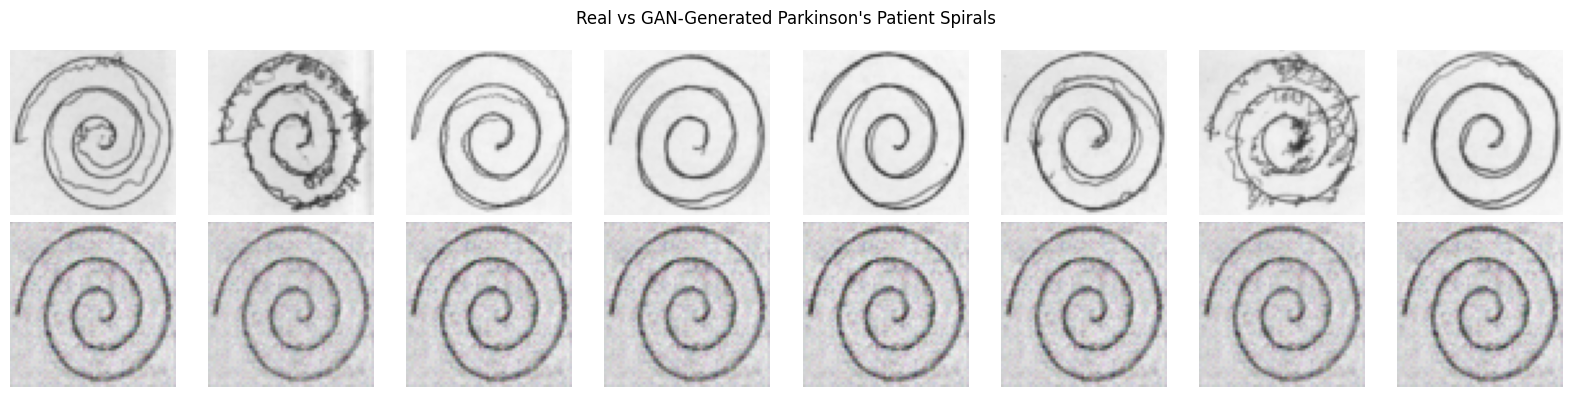

In [17]:
# Real patient samples
real_iter = iter(patient_loader)
real_samples = next(real_iter)[:8].cpu()

# GAN-generated patient samples
G.eval()
with torch.no_grad():
    noise = torch.randn(8, NOISE_DIM, device=DEVICE)
    fake_samples = G(noise).cpu()

denorm = lambda t: (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(denorm(real_samples[i]));  axes[0, i].axis("off")
    axes[1, i].imshow(denorm(fake_samples[i]));  axes[1, i].axis("off")
axes[0, 0].set_ylabel("Real", fontsize=11)
axes[1, 0].set_ylabel("GAN-Generated", fontsize=11)
plt.suptitle("Real vs GAN-Generated Parkinson's Patient Spirals")
plt.tight_layout(); plt.show()


In [18]:
os.makedirs("saved_models", exist_ok=True)
torch.save(ae_model.state_dict(), "saved_models/Autoencoder.pth")
torch.save(G.state_dict(),        "saved_models/GAN_Generator.pth")
torch.save(D.state_dict(),        "saved_models/GAN_Discriminator.pth")
print("Saved: saved_models/Autoencoder.pth")
print("Saved: saved_models/GAN_Generator.pth")
print("Saved: saved_models/GAN_Discriminator.pth")


Saved: saved_models/Autoencoder.pth
Saved: saved_models/GAN_Generator.pth
Saved: saved_models/GAN_Discriminator.pth


Autoencoder loaded successfully.
── Patient Sample ──


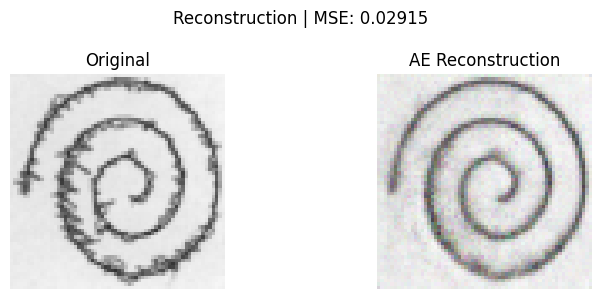

── Control Sample ──


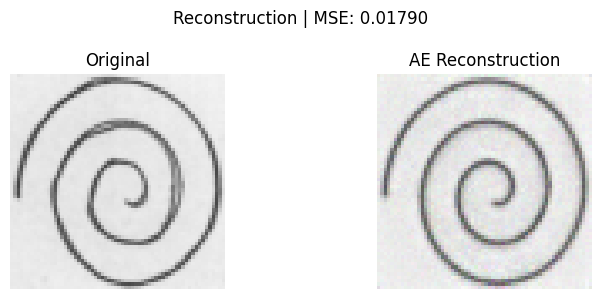

In [19]:
# Load from disk (demonstrates reproducibility)
ae_infer = Autoencoder(LATENT_DIM).to(DEVICE)
ae_infer.load_state_dict(torch.load("saved_models/Autoencoder.pth", map_location=DEVICE))
ae_infer.eval()
print("Autoencoder loaded successfully.")

infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def ae_predict_single(image_path):
    img   = Image.open(image_path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        recon, z = ae_infer(tensor)
    denorm = lambda t: (t.squeeze().cpu() * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(denorm(tensor)); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(denorm(recon));  axes[1].set_title("AE Reconstruction"); axes[1].axis("off")
    plt.suptitle(f"Reconstruction | MSE: {((recon - tensor)**2).mean().item():.5f}")
    plt.tight_layout(); plt.show()
    return z.cpu().numpy()

# Run on one patient and one control
sample_patient = os.path.join(DATA_DIR, "SpiralPatients",
                               os.listdir(os.path.join(DATA_DIR, "SpiralPatients"))[0])
sample_control = os.path.join(DATA_DIR, "SpiralControl",
                               os.listdir(os.path.join(DATA_DIR, "SpiralControl"))[0])

print("── Patient Sample ──")
_ = ae_predict_single(sample_patient)
print("── Control Sample ──")
_ = ae_predict_single(sample_control)


GAN Generator loaded successfully.


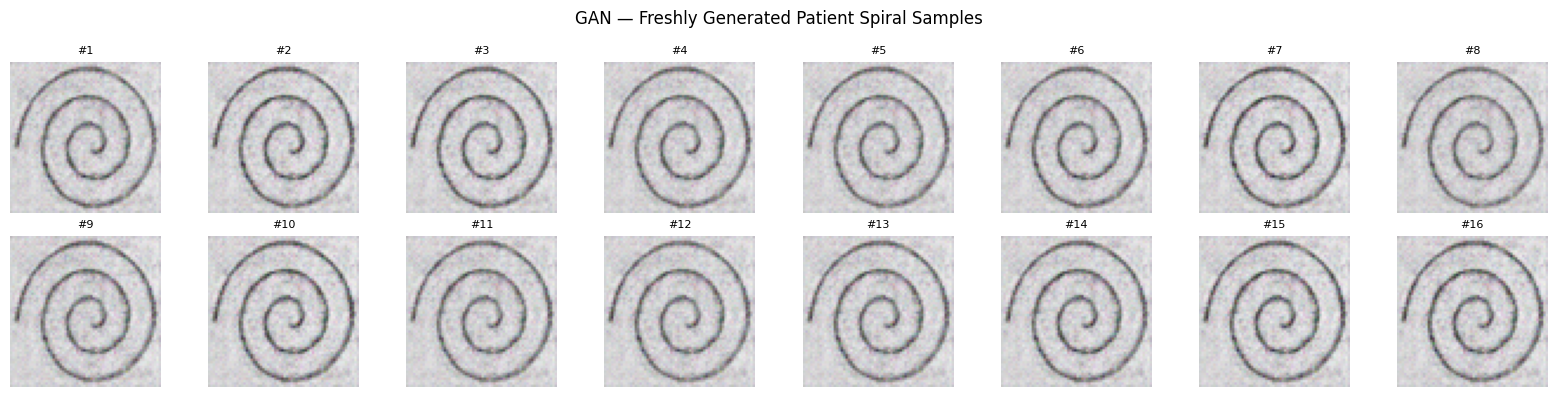

In [20]:
G_infer = Generator(NOISE_DIM).to(DEVICE)
G_infer.load_state_dict(torch.load("saved_models/GAN_Generator.pth", map_location=DEVICE))
G_infer.eval()
print("GAN Generator loaded successfully.")

def generate_patient_images(n=16):
    noise = torch.randn(n, NOISE_DIM, device=DEVICE)
    with torch.no_grad():
        imgs = G_infer(noise).cpu()
    denorm = lambda t: (t * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    for i, ax in enumerate(axes.flatten()):
        if i < n:
            ax.imshow(denorm(imgs[i]))
            ax.set_title(f"#{i+1}", fontsize=8)
        ax.axis("off")
    plt.suptitle("GAN — Freshly Generated Patient Spiral Samples")
    plt.tight_layout(); plt.show()

generate_patient_images(16)
